In [32]:
from graphs import generate_grid_graph, grid_graph_max_cut, grid_renderer, state_history_renderer, render_state, render_state_prog_gif
from cim import CIM
from solvers import SG3
from graphs import read_graph_from_rudy, eval_max_cut
from schedules import schedule_linear
from transfers import Clipped
import torch
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [33]:
torch.manual_seed(0xDEADBEEF + 0)

size = 20
J = generate_grid_graph(size)
max_cut = grid_graph_max_cut(size)
print(f"{max_cut=}")
pump_schedule=schedule_linear(slope=0.01, t_mid=50, max_val = 1.01)
noise_magnitude = 0.003
steps=25000
step_size=0.02

max_cut=760


In [34]:
# foo = CIM(-0.1 * J, solver=SG3)
# foo.solve()
# print(foo.model.state)
# print("SG3:", eval_max_cut(foo.model.state.tolist(), J))

## DOPO CIM

In [41]:
dopo_cim = CIM(-0.1 * J, pump_schedule=pump_schedule)
dopo_cim.solve(noise_magnitude=noise_magnitude, steps=steps, step_size=step_size)
while (cut := eval_max_cut(dopo_cim.model.state.tolist(), J)) != max_cut:
    print(cut)
    dopo_cim.solve(noise_magnitude=noise_magnitude, steps=steps, step_size=step_size)
print(dopo_cim.model.state)
print("DOPO:", eval_max_cut(dopo_cim.model.state.tolist(), J))

tensor([-0.4898,  0.5607, -0.5671,  0.5735, -0.5686,  0.5679, -0.5677,  0.5715,
        -0.5699,  0.5704, -0.5702,  0.5645, -0.5656,  0.5649, -0.5639,  0.5662,
        -0.5675,  0.5625, -0.5577,  0.4881,  0.5585, -0.6271,  0.6332, -0.6362,
         0.6356, -0.6333,  0.6352, -0.6351,  0.6350, -0.6359,  0.6298, -0.6324,
         0.6334, -0.6353,  0.6318, -0.6328,  0.6337, -0.6343,  0.6262, -0.5513,
        -0.5658,  0.6308, -0.6386,  0.6412, -0.6423,  0.6381, -0.6388,  0.6412,
        -0.6423,  0.6408, -0.6413,  0.6388, -0.6367,  0.6390, -0.6408,  0.6386,
        -0.6355,  0.6372, -0.6328,  0.5667,  0.5667, -0.6304,  0.6395, -0.6382,
         0.6399, -0.6382,  0.6391, -0.6386,  0.6377, -0.6388,  0.6460, -0.6422,
         0.6411, -0.6373,  0.6416, -0.6406,  0.6361, -0.6382,  0.6343, -0.5703,
        -0.5681,  0.6330, -0.6416,  0.6391, -0.6426,  0.6383, -0.6380,  0.6393,
        -0.6417,  0.6370, -0.6420,  0.6405, -0.6406,  0.6417, -0.6419,  0.6405,
        -0.6396,  0.6393, -0.6364,  0.56

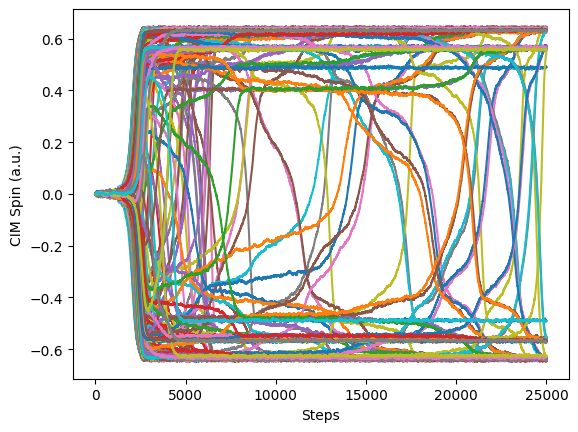

In [43]:
fig, ax = plt.subplots()
ax.plot(dopo_cim.model.Result.state_history)
ax.set_xlabel("Steps")
ax.set_ylabel("CIM Spin (a.u.)")
fig.savefig('ims/DOPO_CIM_Sqare_Lattice_States.png', dpi=900)

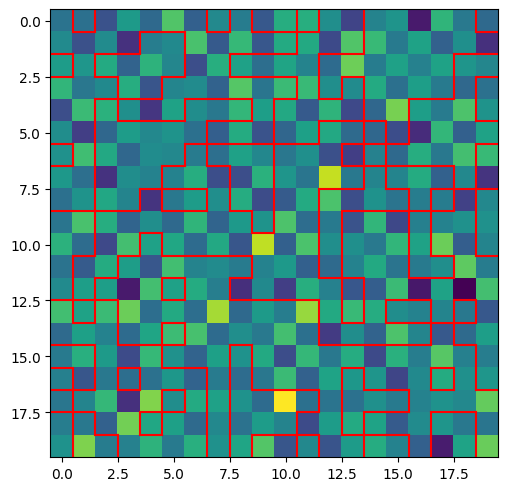

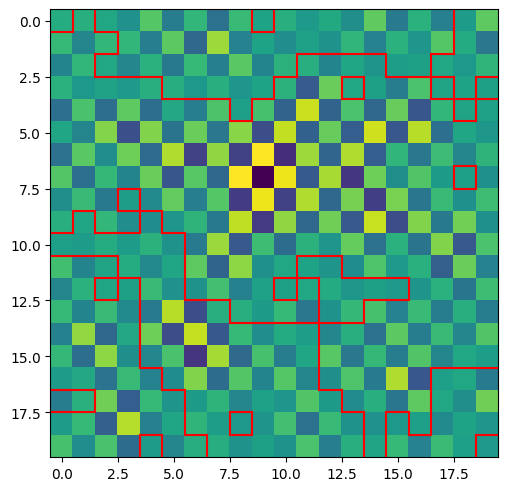

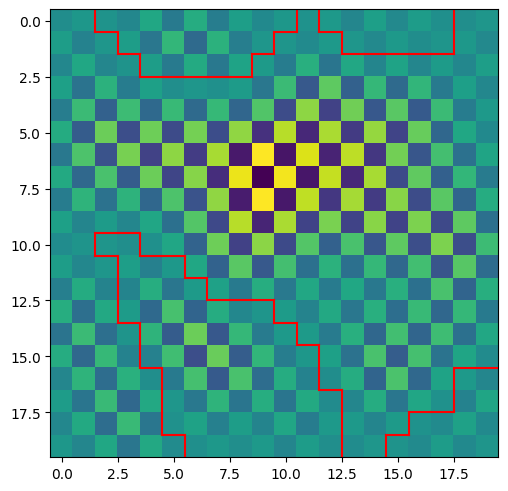

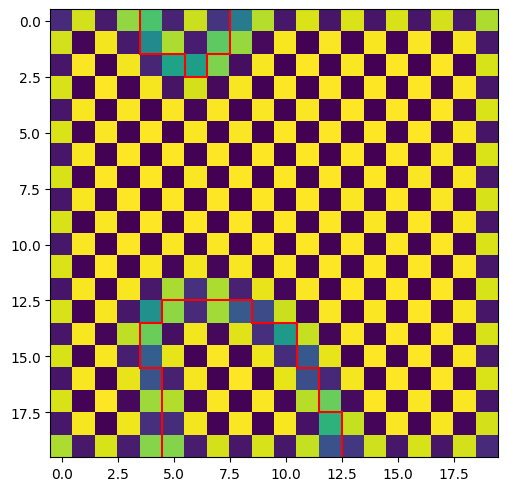

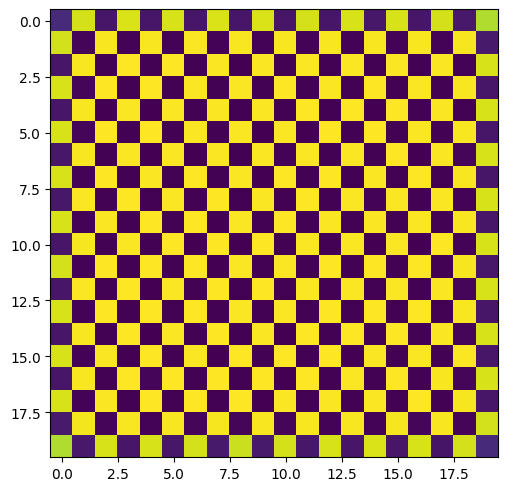

In [44]:
for step in (100, 1500, 2000, 5000, 24990):
    fig, _ = render_state(step, dopo_cim.model.Result.state_history, [grid_renderer], ncols=1, with_domain_border=True)
    fig.savefig(f"ims/DOPO_CIM_Sqare_Lattice_Grid_{size}_step_{step}.png", dpi=900, transparent=True)

In [ ]:
render_state_prog_gif(dopo_cim.model.Result.state_history, [grid_renderer, state_history_renderer], 
                      with_domain_border=True, ncols=2, step=500, num_rendered=52,
                      filename='ims/DOPO_CIM_Sqare_Lattice_All.gif')

In [ ]:
render_state_prog_gif(dopo_cim.model.Result.state_history, [grid_renderer], 
                      title="CIM Square Lattice Progression", ncols=1, step=250,
                      with_domain_border=True,
                      filename='ims/DOPO_CIM_Sqare_Lattice_Grid.gif')

## Clipped CIM

In [38]:
torch.manual_seed(0xDEADBEEF + 0)
foo = CIM(-0.1 * J, pump_schedule=pump_schedule, transfer=Clipped)
foo.solve(noise_magnitude=noise_magnitude, steps=steps, step_size=step_size)
# while (cut := eval_max_cut(foo.model.state.tolist(), J)) != max_cut:
#     print(cut)
#     foo.solve(noise_magnitude=noise_magnitude, steps=steps, step_size=step_size)
print(foo.model.state)
print("DOPO:", eval_max_cut(foo.model.state.tolist(), J))

tensor([ 0.9988, -0.9973,  1.0018, -0.9898,  1.0047, -0.9920,  0.9880, -1.0006,
         1.0039, -0.9926,  0.9887, -0.9958,  0.9973, -1.0006,  0.9895, -1.0025,
         0.9967, -0.9948,  0.9954, -1.0049, -1.0021,  0.9895, -0.9928,  0.9912,
        -1.0044,  1.0046, -1.0018,  0.9998, -1.0030,  1.0005, -0.9931,  0.9984,
        -1.0040,  0.9936, -0.9906,  1.0037, -0.9960,  0.9950, -1.0036,  0.9867,
         1.0020, -1.0068,  1.0021, -0.9967,  1.0053, -0.9943,  1.0076, -0.9985,
         1.0058, -0.9984,  0.9901, -0.9929,  1.0026, -1.0009,  0.9880, -1.0047,
         1.0011, -1.0016,  1.0021, -0.9994, -0.9996,  1.0065, -0.9901,  0.9972,
        -0.9884,  0.9960, -1.0043,  0.9891, -0.9955,  0.9889, -0.9920,  0.9894,
        -0.9974,  0.9974, -0.9912,  1.0045, -0.9961,  1.0009, -0.9949,  0.9971,
         0.9920, -0.9975,  0.9999, -0.9973,  0.9919, -0.9887,  0.9883, -0.9856,
         1.0028, -1.0012,  0.9992, -1.0042,  0.9928, -1.0078,  0.9890, -0.9970,
         0.9940, -0.9912,  0.9898, -1.00

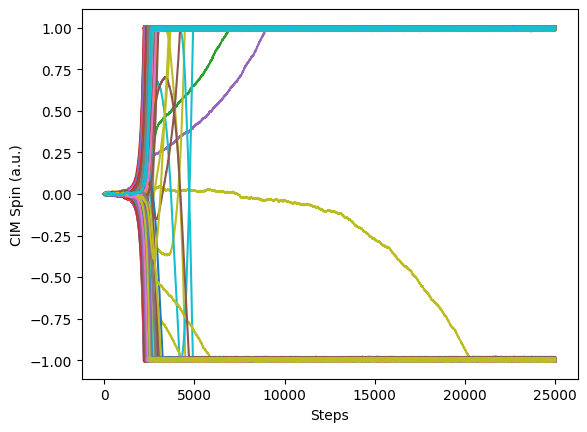

In [39]:
fig, ax = plt.subplots()
ax.plot(foo.model.Result.state_history)
ax.set_xlabel("Steps")
ax.set_ylabel("CIM Spin (a.u.)")
fig.savefig('ims/Clipped_CIM_Sqare_Lattice_States.png', dpi=900)

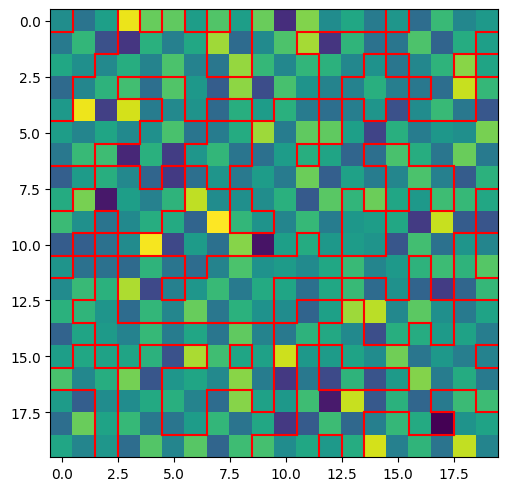

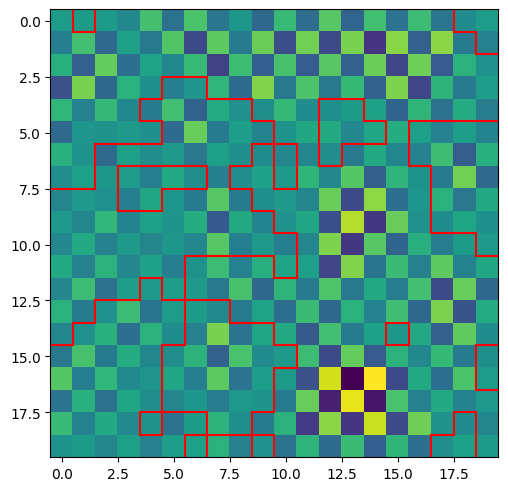

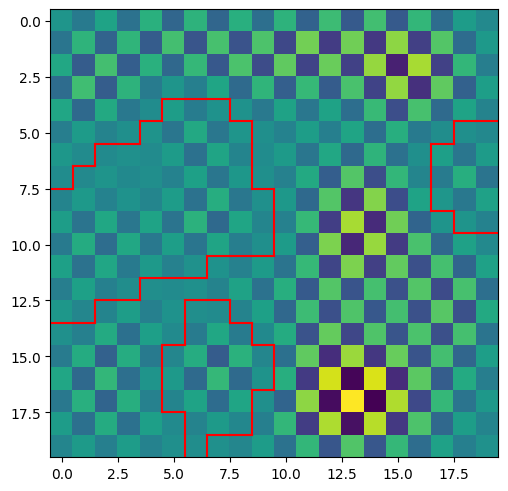

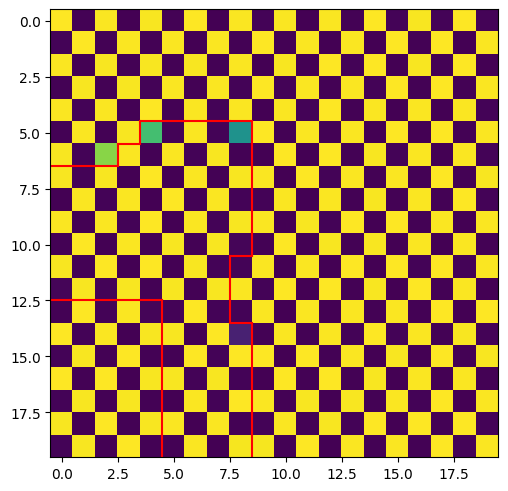

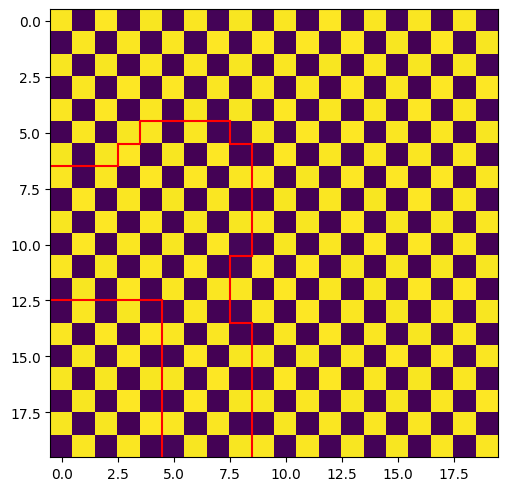

In [40]:
for step in (100, 1500, 2000, 5000, 24990):
    fig, _ = render_state(step, foo.model.Result.state_history, [grid_renderer], ncols=1, with_domain_border=True)
    fig.savefig(f"ims/Clipped_CIM_Sqare_Lattice_Grid_{size}_step_{step}.png", dpi=900, transparent=True)

In [ ]:
render_state_prog_gif(foo.model.Result.state_history, [grid_renderer, state_history_renderer], 
                      with_domain_border=True, ncols=2, step=500, num_rendered=52,
                      filename='ims/Clipped_CIM_Sqare_Lattice_All.gif')

In [ ]:
render_state_prog_gif(foo.model.Result.state_history, [grid_renderer], 
                      title="CIM Square Lattice Progression", ncols=1, step=1000,
                      with_domain_border=True, filename="ims/Clipped_CIM_Sqare_Lattice_Grid.gif")